# Learning Unit 4: Explainability
## Weakly-supervised visualisation
The goal of this exercise is to implement methods that allow to gain insights which parts of an input image to a Deep Neural Network are pivotal for its classification decision. Because of their conception as black-box-systems, this is important for user acceptance of AI models - especially in medical applications.

When we, for example, classify pneumonia in a X-ray scan, we want to gain insight into which regions of the scan are the most relevant for this decision.

![explainability](https://drive.google.com/uc?export=view&id=1oDUfMmOpopV8Dnv4rvHmqmxMcIK8JLYI)

In [11]:
!pip install wget
!pip install torchinfo
import torch
import torchvision
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
from collections import OrderedDict
import matplotlib.cm as mpl_color_map
import os
import wget
import zipfile
from tqdm.notebook import trange, tqdm
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
if torch.cuda.is_available():
  print('CUDA GPU found: ', torch.cuda.get_device_name(['0']))
  device='cuda'
else:
  print('CUDA not found! It is highly recommended to enable CUDA for the exercises')
  device = 'cpu'


CUDA GPU found:  Tesla T4


In [12]:
dataset_url = 'https://cloud.imi.uni-luebeck.de/s/KwD3fs4q6ctqmA8/download'

def get_data(data_url):
    filename = './MDL3_data.zip'
    if not os.path.exists(filename):
        filename = wget.download(data_url)
    zipfile.ZipFile(filename,'r').extractall()

get_data(dataset_url)

In [13]:
# Function for Heatmap Overlays (expects gray-scale image as numpy and heatmap as torch array)
def overlayParula(grayim_numpy: np.ndarray, heatmap_torch: torch.Tensor, smooth: bool = False):
    heat_max = torch.kthvalue(heatmap_torch.view(-1), int(.95 * heatmap_torch.numel()))[0]
    heat_min = torch.min(heatmap_torch)
    heatmap_torch = torch.clamp((heatmap_torch - heat_min) / (heat_max - heat_min), 0, 1)
    if (smooth == True):
        heatmap_torch = F.avg_pool2d(
            F.avg_pool2d(F.max_pool2d(heatmap_torch.unsqueeze(0).unsqueeze(0), 3, stride=1, padding=1), 3, stride=1,
                         padding=1), 3, stride=1, padding=1).squeeze()

    x = np.linspace(0.0, 1.0, 256)
    rgb_jet = mpl_color_map.get_cmap(plt.get_cmap('jet'))(x)[:, :3]
    rgb_gray = mpl_color_map.get_cmap(plt.get_cmap('gray'))(x)[:, :3]
    #rgb_viridis
    rgb_heat = rgb_jet[(heatmap_torch * 255).numpy().astype('uint8'), :]
    rgb_base = rgb_gray[(grayim_numpy * 255).astype('uint8'), :]

    rgb0 = (rgb_heat * 127.5 + rgb_base * 127.5).astype('uint8')
    weight = torch.tanh((heatmap_torch - 0.5) * 3) * 0.5 + 0.5
    alpha = torch.clamp(1.0 - 0.5 * weight, 0, 1.0)
    overlay = rgb_base * alpha.unsqueeze(2).numpy() + rgb_heat * (1.0 - alpha).unsqueeze(2).numpy()

    return overlay


# Function to compute the Dice value given the ground truth segmentation of a slice
# and the guided_backpropagation_map or the CAM map as <pred>
def oracle_dice(pred, gt_th):
    val, idx = torch.sort(pred.data.flatten(), descending=True)
    gt_sort = gt_th.flatten()[idx]
    intersect = torch.cumsum(gt_sort, 0).float()
    cardinal = (gt_th.flatten() > 0.5).float().sum() + torch.arange(pred.numel(), device=gt_th.device).float()
    all_dices = 2 * intersect / torch.clamp(cardinal, min=.001)
    return all_dices.max(), val[all_dices.argmax()]

## Task 0: Implement dataset and visualize the given pancreas train & test data
The classification task we are going to look at is the decision of whether the pancreas is present or not in CT slices.
We start with implementing the `PancreasDataSet`, which loads the training and test data respectively to its `mode`. For training data only the labels (pancreas/no pancreas) are given, for the test datasets also segmentation masks of the pancreas are provided. Because our pretrained CNN on ImageNet expects an RGB-image, we stack three neighboring slices of the CT as feature channels.
The training data are given as a list of tensors with shape $[64\times3\times224\times224]$ for the image and $[64]$ for the labels. The files are named `train_imgs.pth`, `train_labels.pth`, `test_imgs.pth`, `test_lanels.pth` and `test_segmentations.pth`.
+ load the data and its labels accordingly to the dataset's mode and concatenate each list to one tensor of dimension $N$ using `torch.cat`
+ divide the images with 255 to map them to $[0, 1]$
+ if `mode=='test'` load the segmentation masks and concatenate them like above
+ complete the `__len__` and `__getitem__` functions
    + **NOTE** the number of returned data differs between the `mode`s. Please use following order for the return statements: images, labels, (segmentations)

For more information on how PyTorch datasets work, you can have a look into the corresponding [PyTorch tutorial](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).

In [14]:
from torch.utils.data import Dataset, DataLoader

class PancreasDataSet(Dataset):
    def __init__(self, mode: str, normalize: bool=True):
        assert mode in ['train', 'test']
        self.mode = mode
        super(PancreasDataSet, self).__init__()


        if mode == 'train':
          # TODO: load data
          self.imgs = torch.load("train_imgs.pth") # load data from file
          self.imgs = torch.cat(self.imgs, dim=0)# concatenate list of tensors to one tensor
          self.imgs = self.imgs.float() / 255 # divide by 255

          # TODO: load labels
          self.labels = torch.load("train_labels.pth")# load data from file
          self.labels = torch.cat(self.labels, dim=0)# concatenate list of tensors to one tensor

        if mode == 'test':
            # TODO: load data
            self.imgs = torch.load("test_imgs.pth") # load data from file
            self.imgs = torch.cat(self.imgs, dim=0)# concatenate list of tensors to one tensor
            self.imgs = self.imgs.float() / 255 # divide by 255

            # TODO: load labels
            self.labels = torch.load("test_labels.pth")# load data from file
            self.labels = torch.cat(self.labels, dim=0)# concatenate list of tensors to one tensor
            # TODO: load segmentations
            self.segmentations = torch.load("test_segmentations.pth")# load data from file
            self.segmentations = torch.cat(self.segmentations, dim=0)# concatenate list of tensors to one tensor
            assert len(self.imgs) == len(self.labels) == len(self.segmentations)
        assert len(self.imgs) == len(self.labels)

        # normalize data
        if normalize:
            # Below we provide the mean and std values from the ImageNet data
            means = torch.Tensor([0.485, 0.456, 0.406])
            stds = torch.Tensor([0.229, 0.224, 0.225])
            self.imgs = (self.imgs - means.view(1, 3, 1, 1)) / stds.view(1, 3, 1, 1)

    def __getitem__(self, index):
        if self.mode == 'train':
            return self.imgs[index], self.labels[index]
            # TODO: return image and label for the given index
        else:
            return self.imgs[index], self.labels[index], self.segmentations[index]
            # TODO: reutrn image, label and segmentation for the given index


    def __len__(self):
        # TODO: return length of the dataset
        return len(self.imgs)

### Visualize some random input training & test slices

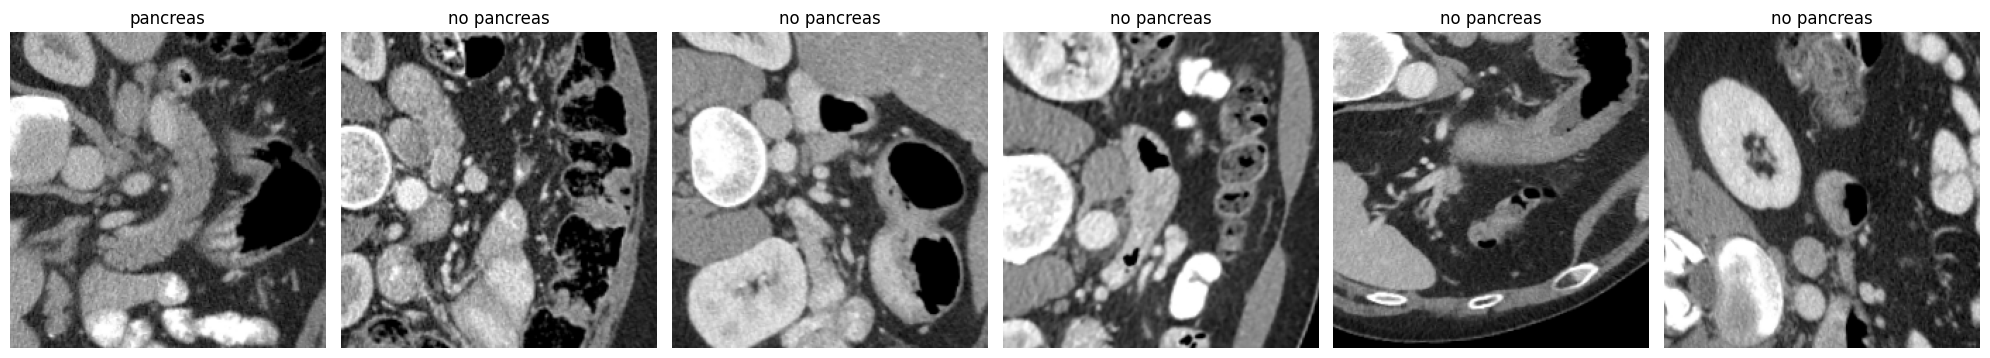

In [15]:
ds = PancreasDataSet('test', normalize=False)
label = ['no pancreas', 'pancreas']
n_plots = 6
rnd_idx = torch.randperm(len(ds))[:n_plots]

fig, axs = plt.subplots(1, n_plots, figsize=(20, 5))
for i, idx in enumerate(rnd_idx):
    img, lbl, _ = ds[idx]
    axs[i].imshow(img[1], cmap='gray')
    axs[i].set_title(label[lbl.item()])
    axs[i].set_axis_off()
fig.tight_layout()

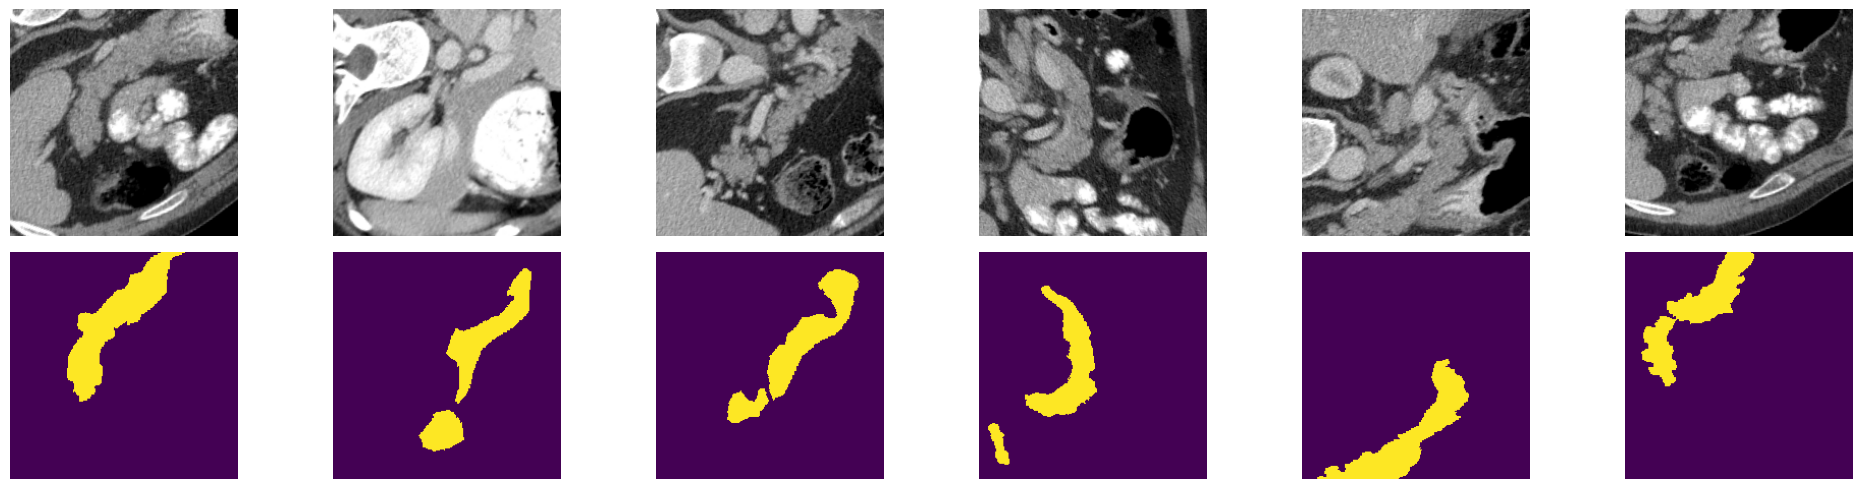

In [16]:
rnd_idx = torch.arange(len(ds))[ds.labels == 1]
rnd_idx = rnd_idx[torch.randperm(len(rnd_idx))[:n_plots]]

fig, axs = plt.subplots(2, n_plots, figsize=(20, 5))
for i, idx in enumerate(rnd_idx):
    axs[0, i].imshow(ds.imgs[idx, 1], cmap='gray')
    axs[0, i].set_axis_off()

    axs[1, i].imshow(ds.segmentations[idx])
    axs[1, i].set_axis_off()
fig.tight_layout()

## Task 1: Finetune a pretrained ResNet on the given data
Before we can fine tune the pretrained network on our data, we have to modify its architecture to our needs.
+ load the ResNet18 pretrained on IMAGENET1K_V1 from the torchvision model zoo
+ get familiar with the architecture's structure
    + print its layers with their settings using the `print` function
    + check the corresponding output shapes with `torchinfo.summary`
  
For further insight into the network architecture, you can check out https://paperswithcode.com/method/resnet.

In [17]:
from torchinfo import summary
# TODO: load model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# TODO: inspect architecture
# print all layers and settings
print(model)

# show output shapes and parameter counts
summary(model, input_size=(1, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 43.5MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

With foresight to the gradCAM method, we need the last feature layer to have a sufficiently large spatial dimensions therefore we need to replace the ResNet.Layer4 Sequential block with an identity operation (`nn.Identity`). Since in addition to a larger spatial output of the last feature layer, we also want a more lightweight model, we modify the building blocks of Layer3:

1. Replace `conv1` in `layer3[0]` with a Conv2D: (in=128,out=256,k_sz=3, stride=1, pad=1, bias=False)
2. Replace `conv2` in `layer3[0]` with a Conv2D: (in=256,out=256,k_sz=3, stride=1, dil=2, pad=2, bias=False)
3. Replace `downsample[0]` in `layer3[0]` with a Conv2D: (in=128,out=256,k_sz=1, stride=1, pad=0, bias=False)
4. Replace `conv1` in `layer3[1]` with a Conv2D: (in=256,out=256,k_sz=3, stride=1, dil=2, pad=2, bias=False)
5. Replace `conv2` in `layer3[1]` with a Conv2D: (in=256,out=256,k_sz=3, stride=1, dil=2, pad=2, bias=False)

Finally: replace the fully connected layer (`nn.Linear`): Inspect the number of input & output channels for the ImageNet classification task and modify this layer accordingly to our "(presence/absence) of the pancreas" classification problem.

Now, we have a ResNet14. Check its architecture using `summary`. You should obtain a total count of $2.783.298$ parameters.

In [18]:
# TODO replace the 4th layer with an identity mapping
model.layer4 = nn.Identity()

#TODO: replace the modules according to the description given above
model.layer3[0].conv1 = nn.Conv2d(128,256,kernel_size=3,stride=1,padding=1,bias=False)
model.layer3[0].conv2 = nn.Conv2d(256,256,kernel_size=3,stride=1,dilation=2,padding=2,bias=False)
model.layer3[0].downsample[0] = nn.Conv2d(128,256,kernel_size=1,stride=1,padding=0,bias=False)
model.layer3[1].conv1 = nn.Conv2d(256,256,kernel_size=3,stride=1,dilation=2,padding=2,bias=False)
model.layer3[1].conv2 = nn.Conv2d(256,256,kernel_size=3,stride=1,dilation=2,padding=2,bias=False)

# TODO: replace the fully connected layer
model.fc = nn.Linear(256, 2)
# TODO: print the summary
print(model)
summary(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─BasicBlock: 2-1                   --
│    │    └─Conv2d: 3-1                  36,864
│    │    └─BatchNorm2d: 3-2             128
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  36,864
│    │    └─BatchNorm2d: 3-5             128
│    └─BasicBlock: 2-2                   --
│    │    └─Conv2d: 3-6                  36,864
│    │    └─BatchNorm2d: 3-7             128
│    │    └─ReLU: 3-8                    --
│    │    └─Conv2d: 3-9                  36,864
│    │    └─BatchNorm2d: 3-10            128
├─Sequential: 1-6                        --
│    └─BasicBlock: 2-3                   --
│    │    └─Conv2d: 3-11                 73,728

Now let's finetune the ResNet14 to our training data:
+ create two dataloader (hint: set `pin_memory=True` for speed up during CPU→GPU transfer)
    + choose a batch size of 32 for training and shuffle the dataset after every epoch
    + you can double the batch size for testing
- use Adam in combination with an exponential learning rate scheduler ($\gamma=0.95$) and cross entropy
- you should easily achieve accuracy scores on the training data of > 0.98 after 3 epochs
- your validation accuracy should be ~80% after 10 epochs

In [19]:
# TODO: create dataloader
train_dataset = PancreasDataSet(mode="train", normalize=True)
test_dataset = PancreasDataSet(mode="test", normalize=True)
dl_train = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
dl_test = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True)
model.to(device)

num_epochs = 10

# TODO: optimizer
optimizer = optim.Adam(model.parameters(),lr=1e-3)

# TODO: learning rate scheduler
lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer=optimizer,gamma=0.95)

# TODO: criterion
criterion = nn.CrossEntropyLoss()

# for reproducibility (do not change)
torch.manual_seed(0)

# statistics
train_loss = torch.zeros(num_epochs, device=device)
train_acc = torch.zeros_like(train_loss)

test_loss = torch.zeros_like(train_loss)
test_acc = torch.zeros_like(train_loss)

# for num_epochs
for epoch in trange(num_epochs, unit='epoch'):

    # train mode
    model.train()

    # for each mini-batch
    for input, target in dl_train:
        input = input.to(device)
        target = target.to(device)

        # TODO: zero the parameter gradients
        optimizer.zero_grad()
        # TODO: forward + backward + optimize

        output = model(input)

        loss = criterion(output, target)

        loss.backward()

        optimizer.step()
        # statistics
        train_loss[epoch] += loss.detach()
        train_acc[epoch] += torch.mean((torch.argmax(output, dim=-1) == target).float())

    # TODO: update learning rate
    lr_scheduler.step()

    train_loss[epoch] /= len(dl_train)
    train_acc[epoch] /= len(dl_train)

    # output
    tqdm.write('Epoch {} (train) -- loss: {:.4f} accuracy: {:.4f}'.format(epoch, train_loss[epoch].item(), train_acc[epoch].item()))

    # validate
    with torch.no_grad():

        # eval mode
        model.eval()

        # for each mini-batch
        for input, target, _ in dl_test:
            input = input.to(device)
            target = target.to(device)

            # TODO: forward
            output = model(input)

            loss = criterion(output, target)
            # statistics
            test_loss[epoch] += loss.detach()
            test_acc[epoch] += torch.mean((torch.argmax(output, dim=-1) == target).float())

        test_loss[epoch] /= len(dl_test)
        test_acc[epoch] /= len(dl_test)

        # output
        tqdm.write('Epoch {} (valid) -- loss: {:.4f} accuracy: {:.4f}\n'.format(epoch, test_loss[epoch].item(), test_acc[epoch].item()))

#save the network
torch.save(model, 'pancreas_model.pt')

  0%|          | 0/10 [00:00<?, ?epoch/s]

Epoch 0 (train) -- loss: 0.2329 accuracy: 0.9180
Epoch 0 (valid) -- loss: 0.7286 accuracy: 0.7594

Epoch 1 (train) -- loss: 0.0297 accuracy: 0.9945
Epoch 1 (valid) -- loss: 2.0672 accuracy: 0.7312

Epoch 2 (train) -- loss: 0.0312 accuracy: 0.9891
Epoch 2 (valid) -- loss: 1.5220 accuracy: 0.7188

Epoch 3 (train) -- loss: 0.0320 accuracy: 0.9871
Epoch 3 (valid) -- loss: 1.2283 accuracy: 0.7406

Epoch 4 (train) -- loss: 0.0148 accuracy: 0.9961
Epoch 4 (valid) -- loss: 2.0745 accuracy: 0.6500

Epoch 5 (train) -- loss: 0.0039 accuracy: 0.9996
Epoch 5 (valid) -- loss: 0.7019 accuracy: 0.8250

Epoch 6 (train) -- loss: 0.0007 accuracy: 1.0000
Epoch 6 (valid) -- loss: 0.7221 accuracy: 0.7750

Epoch 7 (train) -- loss: 0.0006 accuracy: 1.0000
Epoch 7 (valid) -- loss: 0.7185 accuracy: 0.7719

Epoch 8 (train) -- loss: 0.0005 accuracy: 1.0000
Epoch 8 (valid) -- loss: 0.6279 accuracy: 0.7781

Epoch 9 (train) -- loss: 0.0003 accuracy: 1.0000
Epoch 9 (valid) -- loss: 0.5872 accuracy: 0.7969




## Task 2: Class Activation Maps
![cam](https://drive.google.com/uc?export=view&id=1CBjTBKCdTHFi6MDoz0hJ1y-Faat56Krz)
Now that we have our trained ResNet14 at hand, we want to visualize the class activation map (CAM).
Therefore, we need to implement the following steps:

+ Beforehand, the fully connected layer operated on 256-channel images without spatial dimensions only due to the `nn.AdaptivePooling` layer. Now, we want to weight each of the $28\times28$ spatial features with their 256-channels using the trained weights from the fully connected layer. In order to do so, extract the weights for the class activation map from the fully connected layer's weight (remember that we are only interested in the weights for the 'pancreas presence' class).
+ Since we are interested in the last convolutional feature layer output, we want to omit the avg_pool & fc layer. (Hint: use `torch.nn.Sequential(*list(model.children())[:-k])`)

In [20]:
# TODO: load the saved net in evaluation mode
model = model.eval()
# TODO: extract the weights of the fully connected layer for cam
cam_weight = model.fc.weight.data
  # TODO: remove the avg and fc layer
#print(list(model.children()))
truncated_model = torch.nn.Sequential(*list(model.children())[:-2])

In [21]:
# provided function for plotting the activation heatmaps and comparing them to the ground truth
def plot_activations(img: torch.Tensor, activation_heatmap: torch.Tensor, segmentation: torch.Tensor):

    img = img[1].squeeze().cpu().numpy()

    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(overlayParula(img, activation_heatmap.cpu().squeeze(), smooth=True))
    axs[0].set_axis_off()
    axs[0].set_title('prediction')

    axs[1].imshow(overlayParula(img, segmentation.cpu(), smooth=False))
    axs[1].set_axis_off()
    axs[1].set_title('ground truth')

Next, we want to generate our segmentation from the latent space.
+ Feed the normalized image through our modified model
+ Generate the CAM, therefore
    + Multiply each feature map with its corresponding weight of the fully connected classifier
    + Sum over all feature maps to create a CAM
    + Upsample the CAM to the spatial dimension of the input image
+ Visualize and compare the CAM with the given ground truth using the provided `plot_activations` function.
+ Finally, use the `oracle_dice` function to compute the DICE score (~0.6mean) between the ground truth and the CAM-based segmentation - remember: you have been using only weak labels during the training stage!

/tmp/ipykernel_598/2293699810.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb_jet = mpl_color_map.get_cmap(plt.get_cmap('jet'))(x)[:, :3]
/tmp/ipykernel_598/2293699810.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb_gray = mpl_color_map.get_cmap(plt.get_cmap('gray'))(x)[:, :3]


mean dice: 0.541864812374115


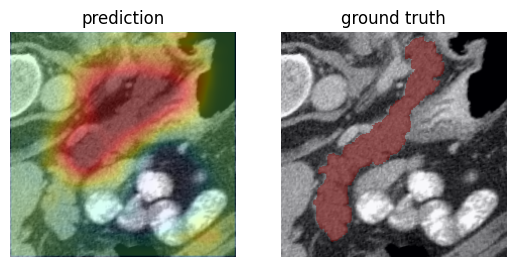

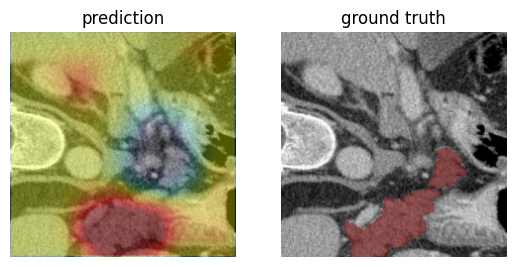

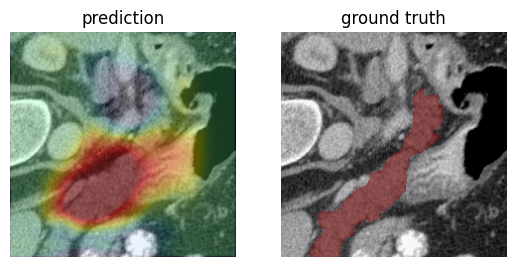

In [22]:
dice_all = []
for test_idx in range(256,262,2):
    # skip img without pancreas
    if(ds.labels[test_idx]==0):
        continue

    img_normalized = dl_test.dataset.imgs[test_idx].unsqueeze(0).to(device)
    img = ds.imgs[test_idx].to(device)
    seg = ds.segmentations[test_idx].to(device)

    with torch.no_grad():
        # TODO: feed the test image through the modified net
        feature_map = truncated_model(img_normalized)
        # TODO: generate cam
        weights = cam_weight[1].view(1, -1, 1, 1).to(device)
        cam = feature_map * weights# multiply feature map and cam weights
        cam = cam.sum(dim=1, keepdim=True)# sum over all feature maps
        cam = F.interpolate(
              cam,
              size=img_normalized.shape[-2:],
              mode="bilinear",
              align_corners=False
          )# upsalte the activation map
        # normalize CAM
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
    # TODO: visualize the overlay with the above given function
    plot_activations(img,cam, seg)
    # TODO: compute the dice score & append it to dice_all


    # compute oracle Dice
    dice, threshold = oracle_dice(cam.squeeze(), seg)

    # store Dice score
    dice_all.append(dice)
print('mean dice:', torch.stack(dice_all).mean().item())

## Task 3: Guided Backpropagation
![guided backpropagation](https://drive.google.com/uc?export=view&id=1kC5h6E9j2lXVLZw0cvkow4N_IcDi1deY)

(see also: http://blog.qure.ai/notes/deep-learning-visualization-gradient-based-methods)

The idea of GuidedBackprop is to supress gradient flow at positions where either of input or incoming gradients were negative.
Luckily, implementing this idea in PyTorch is quite comfortable, since it allows to write own layers - and especially also to define the backpropagation step on the Python-level, i.e. without having to code in CUDA explicitly, when ultimate performance is not necessary.

1. In order to use our pretrained ResNet14, we need to replace the ReLU functions by customized ReLUs that suppress the negative gradient flows according to the above stated cases.

2. Afterward, we need to implement the guided backpropagation steps.

### Implementing the custom ReLU-Layer
(See https://pytorch.org/docs/stable/notes/extending.html for further examples on how to implement custom functions & layers and http://cs231n.github.io/optimization-2/#backprop to refresh your knowledge on local backpropagation using the chain rule if needed.)

The cell below contains a simple example of a modified square function. Instead of computing the derivative of $x^2$ as $\frac{\partial}{\partial x}(x^2) = 2x$, our the customized square function sets this to $4x$ during the backward step.

In [23]:
#example for a custom function and its nn-module
class SquareFunction(torch.autograd.Function):
    # Note that both forward and backward are @staticmethods
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        output = input**2
        return output

    # This function has only a single output, so it gets only one gradient
    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        # with the correct derivative, this should be grad_output*2.0*input[0].float()
        print(input)
        grad_input = grad_output*4.0*input.float()
        return grad_input


class SquareLayer(torch.nn.Module):
    def __init__(self):
        super(SquareLayer, self).__init__()

    def forward(self, x):
        SqFct = SquareFunction.apply
        x = SqFct(x)
        return x

class CorrectSquareLayer(torch.nn.Module):
    def __init__(self):
        super(CorrectSquareLayer, self).__init__()

    def forward(self, x):
        x = x**2
        return x

test1 = torch.arange(4).view(2,2).float()
test1.requires_grad = True

mySQLayer1 = SquareLayer()
out1 = mySQLayer1(test1)
print('input:', test1)
print('output:', out1)
back1 = torch.ones(2,2)
out1.backward(back1)
print('your gradient:', test1.grad)
print('')

test2 = torch.arange(4).view(2,2).float()
test2.requires_grad = True

mySQLayer2 = CorrectSquareLayer()
out2 = mySQLayer2(test2)
back2 = torch.ones(2,2)
out2.backward(back2)
print('correct gradient:', test2.grad)

# you should get 2x the correct gradient

input: tensor([[0., 1.],
        [2., 3.]], requires_grad=True)
output: tensor([[0., 1.],
        [4., 9.]], grad_fn=<SquareFunctionBackward>)
tensor([[0., 1.],
        [2., 3.]], requires_grad=True)
your gradient: tensor([[ 0.,  4.],
        [ 8., 12.]])

correct gradient: tensor([[0., 2.],
        [4., 6.]])



Based on the customized square function as an example, you now have to implement a custom `GradReluLayer`, that cancels out gradient flow where either the input values or the gradient values at the layer's output are negative (cf. image above).

In [24]:
#define custom relu function and its nn-module
class GradReluFunction(torch.autograd.Function):
    # Note that both forward and backward are @staticmethods
    @staticmethod
    def forward(ctx, input):
        # TODO
        ctx.save_for_backward(input)
        return torch.relu(input)

    # This function has only a single output, so it gets only one gradient
    @staticmethod
    def backward(ctx, grad_output):
        # TODO
        # Hint: The normal ReLU backwards step would be
        input, = ctx.saved_tensors

        grad_input = grad_output.clone()

        # cancel gradients where input < 0
        grad_input[input < 0] = 0

        # cancel gradients where output gradient < 0
        grad_input[grad_output < 0] = 0

        return grad_input

class GradReluLayer(torch.nn.Module):
    # TODO: define __init__ and forward
    def __init__(self):
        super(GradReluLayer, self).__init__()
    def forward(self, input):
        return GradReluFunction.apply(input)

In [25]:
t_in1 = torch.Tensor([[-2,1],[2,2]])
t_in1.requires_grad = True
t_out1 = GradReluLayer()(t_in1)
t_in2 = torch.Tensor([[-2,1],[2,2]])
t_in2.requires_grad = True
t_out2 = nn.ReLU()(t_in2)

t_out1.backward(torch.Tensor([[-1,1],[1,-1]]))
t_out2.backward(torch.Tensor([[-1,1],[1,-1]]))

print('input:', t_in1)
# output should be identical to ReLU
print('output (GradRelu):', t_out1)
print('output (ReLU):', t_out2)
# should zero all negative gradients
print('gradient (GradRelu):', t_in1.grad)
print('gradient (ReLU):', t_in2.grad)

input: tensor([[-2.,  1.],
        [ 2.,  2.]], requires_grad=True)
output (GradRelu): tensor([[0., 1.],
        [2., 2.]], grad_fn=<GradReluFunctionBackward>)
output (ReLU): tensor([[0., 1.],
        [2., 2.]], grad_fn=<ReluBackward0>)
gradient (GradRelu): tensor([[0., 1.],
        [1., 0.]])
gradient (ReLU): tensor([[ 0.,  1.],
        [ 1., -1.]])


In [26]:
#GIVEN FUNCTION to replace all default ReLUs
def replaceFunc(model):
    if(isinstance(model,nn.Sequential)):
        if(len(model)>1):
            for i in range(len(model)):
                replaceFunc(model[i])
    for i,j in model._modules.items():
        if(isinstance(j,nn.ReLU)):
            model._modules[i] = GradReluLayer()

        if(isinstance(j,nn.Sequential)):
            model._modules[i] = replaceFunc(model._modules[i])
    return model

Having the customized ReLU-layer at hands, we are now able to implement the guided backward propagation scheme.
1. Define a function `guided_backprop` that expects
    + a test_image ([1,3,224,224])
    + the pretrained ResNet with customized ReLUs
    + a target_class
    + the output will be the guided gradient image
2. as a first step when calling the function, make sure that gradients will be computed for the input image
3. forward propagate the image through the pretrained model (in evaluation mode!)
4. having constructed the autograd graph, we set the gradients of the model to zero
5. next, we backpropagate a one-hot-tensor (for the correct class) through this graph towards the input. Therefore, we set our one-hot-tensor as `gradient` in the `backward` call.
6. finally, return the summed along the channels (absolute values) gradient image as output

In [29]:
def guided_backprop(input_img, pretrained_model, target_class):
    #APPLY GUIDED BACKPROP!

    # ensure gradient flow up until input
    input_img.requires_grad_(True)

    # TODO: set model in evaluation mode!
    pretrained_model.eval()
    # TODO: forward pass
    output = pretrained_model(input_img)
    # create one-hot target for backprop
    one_hot = torch.zeros_like(output)
    one_hot[:, target_class] = 1

    # TODO: zero_grad
    pretrained_model.zero_grad()
    # TODO backward pass (set the gradient to the target one_hot)
    output.backward(gradient=one_hot)
    #sum along abs values on channels
    guided_grad = input_img.grad.abs().sum(1)

    return guided_grad


Plug all parts together and visualize the guided backpropagation map for a test image.
Choosing the same test patient as for CAM and once again computing the DICE score, you should achieve values ~0.4+.

/tmp/ipykernel_598/2293699810.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb_jet = mpl_color_map.get_cmap(plt.get_cmap('jet'))(x)[:, :3]
/tmp/ipykernel_598/2293699810.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb_gray = mpl_color_map.get_cmap(plt.get_cmap('gray'))(x)[:, :3]


mean dice: 0.42098468542099


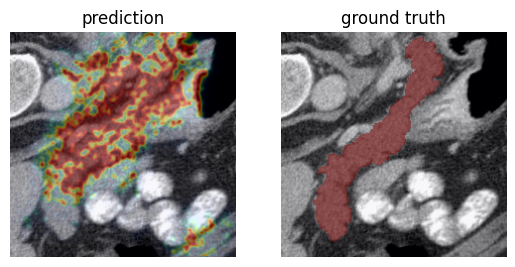

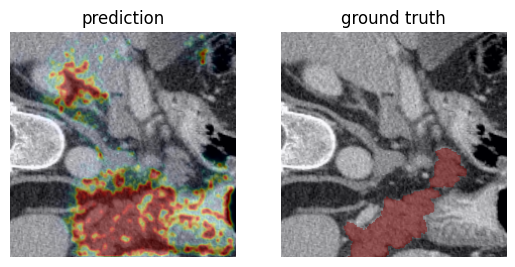

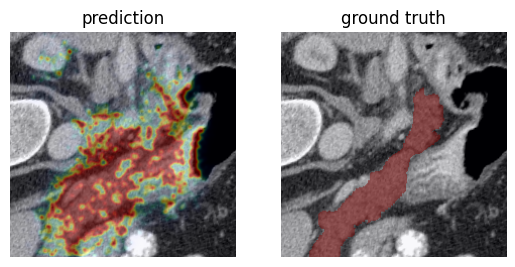

In [33]:
# load the net
model = torch.load('pancreas_model.pt', weights_only=False, map_location=device)
model.eval()
# TODO: replace its relu functions
replaced_model = replaceFunc(model)
torch.manual_seed(50)
dice_all = []

for test_idx in range(256,262,2):
    # skip img without pancreas
    if(ds.labels[test_idx]==0):
        continue

    img_normalized = dl_test.dataset.imgs[test_idx].unsqueeze(0).to(device)
    img = ds.imgs[test_idx].to(device)
    seg = ds.segmentations[test_idx].to(device)

    # TODO: call the guided backprop funktion
    grad = guided_backprop(img_normalized, replaced_model, 1 )
    # TODO: visualize the map (use the function from task 2)
    plot_activations(img,grad, seg)
    # TODO: compute the dice value & append it to dice_all
    dice, threshold = oracle_dice(grad.squeeze(), seg)
    dice_all.append(dice)
print('mean dice:',torch.mean(torch.stack(dice_all)).item())